# Counterfactual corrective BC: SACSoN -> TrajectoryCrafter warps -> ViNT policy

Combines `01_mbra_reannotate_and_embed.ipynb` (MBRA relabelling) and the
counterfactual idea from `02_counterfactual_generation.ipynb`. The
drift-then-recover history frames are produced by
[**TrajectoryCrafter**](https://github.com/TrajectoryCrafter/TrajectoryCrafter):
per window we estimate depth (DepthCrafter), forward-warp the **real** history
frames onto a perturbed camera path, and refine / fill disocclusions with its
CogVideoX-Fun-5B video-diffusion stage. The counterfactual frames are therefore
grounded in the real scene geometry (not a learned world model).

Pipeline per trajectory:
1. **MBRA relabel** every frame -> `(v, omega)`; `dt` pinned from the real `position`
   path length (the HDF5 group attrs carry real `position` + `yaw`).
2. For each window: `perturb_track` bulges the path to one side (peak at the
   anchor) and returns it to the real path; TrajectoryCrafter renders the drifted
   history frames along that camera path.
3. Save **both** a `nominal` sample (real frames -> real waypoints) and a
   `counterfactual` sample (warped+refined frames -> recovery waypoints).
4. Samples are pushed to an **HF dataset repo** (`DATA_REPO`) -- the data is kept.
5. A **ViNT policy is trained from scratch** on the accumulated samples and
   pushed to an **HF model repo** (`REPO_NAME`).

A Drive manifest tracks processed trajectories so generation + training span
sessions. SACSoN frames are 120x160 and get upscaled for the renderer, so expect
some softness / hallucinated detail in the disoccluded regions.


## 1. Setup

In [2]:
# Colab.
!pip install -q "efficientnet-pytorch==0.7.1" "huggingface_hub>=0.24" h5py opencv-python-headless pyyaml safetensors diffusers einops timm python-dotenv
!nvidia-smi


import argparse
import gc
import glob
import json
import math
import os
import random
import shutil
import subprocess
import sys
import time
from collections import defaultdict

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import yaml
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

from google.colab import drive
drive.mount("/content/drive")

MBRA_REPO = "/content/Learning-to-Drive-Anywhere-with-MBRA"
if not os.path.exists(MBRA_REPO):
    subprocess.run(["git", "clone", "-q",
                    "https://github.com/vaishnavi-suresh/Learning-to-Drive-Anywhere-with-MBRA.git", MBRA_REPO], check=True)
sys.path.insert(0, os.path.join(MBRA_REPO, "train"))

# TrajectoryCrafter. NB: its DepthCrafter submodule is pinned to an ssh:// URL that
# Colab can't fetch -- rewrite github ssh -> https so --recursive / submodule update work.
subprocess.run(["git", "config", "--global", "url.https://github.com/.insteadOf", "git@github.com:"], check=False)
TC_REPO = "/content/TrajectoryCrafter"
_DC = os.path.join(TC_REPO, "DepthCrafter")
if not os.path.exists(TC_REPO):
    subprocess.run(["git", "clone", "-q", "--recursive",
                    "https://github.com/TrajectoryCrafter/TrajectoryCrafter.git", TC_REPO], check=True)
subprocess.run(["git", "-C", TC_REPO, "submodule", "sync", "-q"], check=False)
subprocess.run(["git", "-C", TC_REPO, "submodule", "update", "--init", "--recursive", "-q"], check=False)
if not os.path.exists(os.path.join(_DC, "depthcrafter", "depth_crafter_ppl.py")):
    shutil.rmtree(_DC, ignore_errors=True)
    subprocess.run(["git", "clone", "-q", "https://github.com/Tencent/DepthCrafter.git", _DC], check=True)
open(os.path.join(_DC, "__init__.py"), "a").close()                       # make `DepthCrafter` an importable package
assert os.path.exists(os.path.join(_DC, "depthcrafter", "depth_crafter_ppl.py")), "DepthCrafter submodule missing"

# TC's requirements.txt pins torch==2.4.0 / deepspeed / gradio / decord etc. that
# break on Colab (Python 3.13, preinstalled torch). Install a filtered set instead.
_DROP = {"torch", "torchvision", "torchaudio", "xformers", "deepspeed", "gradio", "tensorboard",
         "decord", "openexr", "imath", "pyexr"}   # no py3.13 wheels / need system libs; unused by our path
_UNPIN = {"av", "transformers", "diffusers", "accelerate", "numpy", "pillow"}


def _req_line(raw):
    raw = raw.split("#")[0].strip()
    if not raw:
        return None
    name = raw.split("==")[0].split(">=")[0].split("<")[0].split("[")[0].strip().lower()
    if name in _DROP:
        return None
    if name in _UNPIN:
        extra = "[" + raw.split("[", 1)[1] if "[" in raw else ""
        return name + extra
    return raw


import importlib.util as _ilu

_TC_STAMP = os.path.join(TC_REPO, ".deps_installed")
if not os.path.exists(_TC_STAMP):
    _reqs = []
    for _f in (os.path.join(TC_REPO, "requirements.txt"), os.path.join(_DC, "requirements.txt")):
        if os.path.exists(_f):
            _reqs += [x for x in (_req_line(l) for l in open(_f)) if x]
    _reqs = list(dict.fromkeys(_reqs + ["av", "imageio[ffmpeg]", "kornia", "scikit-image"]))
    _r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_reqs], capture_output=True, text=True)
    if _r.returncode:
        print("batch install failed; retrying package-by-package (failures skipped)...")
        _bad = [p for p in _reqs
                if subprocess.run([sys.executable, "-m", "pip", "install", "-q", p],
                                  capture_output=True, text=True).returncode]
        if _bad:
            print("could not install (non-fatal unless needed below):", _bad)
    _need = ["diffusers", "transformers", "accelerate", "omegaconf", "einops",
             "kornia", "av", "imageio", "safetensors", "timm"]
    _missing = [m for m in _need if _ilu.find_spec(m) is None]
    if _missing:
        raise RuntimeError("required packages still missing after install: %s -- pip logs above" % _missing)
    open(_TC_STAMP, "w").close()
    print("TrajectoryCrafter deps installed -- if imports fail below, restart the runtime and re-run this cell.")

try:
    import decord as _decmod  # noqa
    _decmod.VideoReader
    _have_decord = True
except Exception:
    _have_decord = False
if not _have_decord:                                 # no decord wheels for Python 3.13 -- shim the API TC uses
    open(os.path.join(TC_REPO, "decord.py"), "w").write(
        "import numpy as np, imageio.v3 as _iio, cv2 as _cv2\n"
        "class _Batch:\n"
        "    def __init__(self, a): self._a = np.asarray(a)\n"
        "    def asnumpy(self): return self._a\n"
        "    @property\n"
        "    def shape(self): return self._a.shape\n"
        "class VideoReader:\n"
        "    def __init__(self, path, ctx=None, width=None, height=None, **kw):\n"
        "        v = np.asarray(_iio.imread(path, plugin='pyav'))\n"
        "        if width and height:\n"
        "            v = np.stack([_cv2.resize(f, (width, height)) for f in v])\n"
        "        self._v = v\n"
        "    def __len__(self): return len(self._v)\n"
        "    def get_batch(self, idx): return _Batch(self._v[np.asarray(list(idx))])\n"
        "def cpu(*a, **k): return None\n"
        "def gpu(*a, **k): return None\n")
    print("decord shim written to", os.path.join(TC_REPO, "decord.py"))
sys.path.insert(0, TC_REPO)

# TrajectoryCrafter's vendored CogVideoX code hits diffusers APIs that diffusers >= 0.33
# turned into hard errors via deprecate(). Soften "already past removal" ValueErrors to
# no-ops. reload() first so this is idempotent even if a prior (broken) patch is live.
import importlib  # noqa: E402
import diffusers  # noqa: E402
import diffusers.utils.deprecation_utils as _du  # noqa: E402
_du = importlib.reload(_du)                     # restore the pristine deprecate()
_TRUE_DEPRECATE = _du.deprecate


def _deprecate_soft(*a, **k):
    try:
        return _TRUE_DEPRECATE(*a, **k)
    except ValueError as _e:
        if "should be removed since diffusers" not in str(_e):
            raise


_du.deprecate = _deprecate_soft
diffusers.utils.deprecate = _deprecate_soft
for _n, _m in list(sys.modules.items()):
    if _n.startswith("diffusers") and hasattr(_m, "deprecate"):
        try:
            _m.deprecate = _deprecate_soft
        except Exception:
            pass
print("diffusers", diffusers.__version__, "(deprecate() softened for TrajectoryCrafter)")

# Colab's torchvision has no video backend -> shim write_video (used by TC's save_video).
import torchvision  # noqa: E402
import torchvision.io as _tvio  # noqa: E402
_wv = getattr(_tvio, "write_video", None)
if _wv is None or not str(getattr(_wv, "__module__", "")).startswith("torchvision"):
    import imageio.v2 as _iio2  # noqa: E402

    def _write_video(filename, video_array, fps, video_codec="h264", options=None, **_kw):
        v = video_array.detach().cpu().numpy() if hasattr(video_array, "detach") else np.asarray(video_array)
        if v.dtype != np.uint8:
            v = (np.clip(v, 0, 1) * 255).astype(np.uint8) if float(np.nanmax(v)) <= 1.5 else np.clip(v, 0, 255).astype(np.uint8)
        v = np.ascontiguousarray(v)
        with _iio2.get_writer(filename, format="FFMPEG", mode="I", fps=float(fps),
                              codec="libx264", macro_block_size=1, pixelformat="yuv420p") as _w:
            for _f in v:
                _w.append_data(_f)

    _write_video._tc_shim = True
    _tvio.write_video = _write_video
    print("torchvision.io.write_video shimmed (imageio-ffmpeg)")

from vint_train.models.exaug.exaug import ExAug_dist_delay  # noqa: F401  (prereq check)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_NAME = torch.cuda.get_device_name(0) if device.type == "cuda" else "cpu"
GPU_MEM_GB = (torch.cuda.get_device_properties(0).total_memory / 1e9) if device.type == "cuda" else 0.0
cv2.setNumThreads(max(1, os.cpu_count() or 2))
torch.backends.cudnn.benchmark = True
if device.type == "cuda":
    _free, _tot = (x / 1e9 for x in torch.cuda.mem_get_info())
    print("device:", device, "|", GPU_NAME, "| %.0f GB total, %.1f GB free" % (_tot, _free))
    if _free < 20:
        print("!! low free VRAM -- the GPU is shared/occupied. `nvidia-smi` and kill stale PIDs, or restart.")
else:
    print("device: cpu")

Wed Sep  9 22:40:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             55W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Config

In [26]:
# --- Dataset ---
HF_DATASET = "konpat/huron-sacson-hdf5"
H5_FILE = "sacson.h5"
MAX_TRAJ = None          # None = whole /train split (~2067). Resumable via the Drive manifest.
N_VAL_TRAJ = 80          # /test trajectories reserved for validation
SAMPLE_STRIDE = 5        # overlapping window stride (frames)
MAX_SAMPLES_PER_TRAJ = 3        # each counterfactual clip is a full CogVideoX-Fun pass -- keep low
METRIC_WAYPOINT_SPACING = 0.255   # sacson value from vint_train/data/data_config.yaml (reference: expected median step)
CALIBRATE_DT_FROM_POSITION = True
SACSON_FPS = 3.0                  # fallback dt = 1/SACSON_FPS

# --- MBRA (fixed by the checkpoint) ---
CONTEXT_SIZE = 5
LEN_TRAJ_PRED = 8
ROBOT_SIZE, DELAY = 0.3, 0.0
VEL_PAST_LINEAR, VEL_PAST_ANGULAR = 0.5, 0.0

# --- Counterfactual window ---
TH_HISTORY = 20          # history frames in a window (obs = last CONTEXT_SIZE+1 of these)
T_FUTURE = 30            # recovery frames after t
WINDOW_N = TH_HISTORY + T_FUTURE
GOAL_HORIZON = 15        # real frame this far past t is the ViNT goal image
MBRA_GOAL_HORIZON = 15
PERTURBATION_LEVELS = {"mild": 0.15, "strong": 0.3}   # peak heading deviation (rad)

# --- TrajectoryCrafter (geometry forward-warp + CogVideoX-Fun refinement) ---
PERT_HOLD = 4              # window frames held at zero perturbation (clip lead-in / identity reference)
TC_CLIP_LEN = 17          # real frames per counterfactual clip; must be 4k+1 (CogVideoX-Fun latent stride)
TC_SAMPLE_SIZE = (384, 512)   # (H, W) the diffusion runs at; downsampled to IMAGE_SIZE for the saved sample
TC_DIFFUSION_STEPS = 30
TC_LOW_VRAM = False       # True = sequential CPU offload (lower peak but breaks CogVideoX-Fun: meta-tensor error). Keep False; free GPU mem / shrink TC_SAMPLE_SIZE if OOM.
TC_GUIDANCE = 6.0
TC_DEPTH_STEPS = 5
TC_SEED = 43
TC_NEAR, TC_FAR = 0.01, 100.0
TC_MODEL_NAME = "alibaba-pai/CogVideoX-Fun-V1.1-5b-InP"
TC_TRANSFORMER = "TrajectoryCrafter/TrajectoryCrafter"
TC_POSE_W2C = False       # forward_warp pose convention: False = camera-to-world (see tc_probe())
TC_DEPTH_SIGN = "auto"    # "auto" | "depth" | "disparity" -- DepthCrafter output sign (auto: fit to the ground plane)
TC_SUPERSAMPLE = 2        # render poses at Nx the frame rate (nearest real frame per step) -> smoother drift
TC_PROMPT = ("a first-person view from a mobile robot driving forward through an "
             "indoor space, smooth steady camera motion, photorealistic")
TC_NEG_PROMPT = ("The video is not of a high quality, it has a low resolution. "
                 "Watermark present in each frame. Strange motion trajectory. ")

# --- Camera: HuRoN uses a ~170-deg FISHEYE. forward_warp assumes a pinhole, so we
#     remap fisheye -> pinhole (equidistant model) before the warp. Tune the two
#     FOVs with show_undistort() until straight lines come out straight.
TC_UNDISTORT = True
SACSON_FISHEYE_FOV_DEG = 170.0    # native fisheye horizontal FOV (equidistant r = f*theta)
SACSON_HFOV_DEG = 100.0           # pinhole HFOV kept after undistort (also the warp intrinsics)
CAMERA_HEIGHT_M = 0.5
CAMERA_FORWARD_OFFSET_M = 0.3

# --- ViNT policy / training ---
IMAGE_SIZE = (96, 96)
VINT_OBS_ENCODING_SIZE = 512
VINT_MHA = 4
BATCH_SIZE = 128
EPOCHS = 80
LR = 3e-4
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 4
ALPHA = 0.5
WAYPOINT_SCALE = 1.0
AUG = True
USE_AMP = True

# --- Paths / publishing ---
DRIVE_ROOT = "/content/drive/MyDrive/sacson_nwm_bc"
TC_HF_CACHE = os.path.join(DRIVE_ROOT, "hf_cache")   # persist the ~35 GB of TrajectoryCrafter / DepthCrafter / CogVideoX weights
os.environ["HF_HOME"] = TC_HF_CACHE
CACHE_DIR = "/content/bc_cache"                 # local working copy of the sample cache
MANIFEST_PATH = os.path.join(DRIVE_ROOT, "processed_manifest.json")
CKPT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")
CLIP_DIR = os.path.join(DRIVE_ROOT, "counterfactual_clips")
SAVE_CLIPS_FOR_FIRST_N = 10
DATA_REPO = "vint-sacson-bc-data"              # HF dataset repo (samples are pushed here, kept)
REPO_NAME = "vint-sacson-corrective"           # HF model repo
PUSH_DATA_EVERY = 20                            # push new npz to the HF dataset repo every N trajectories
RESUME_FROM_HF = True
SEED = 0

for d in (DRIVE_ROOT, TC_HF_CACHE, CACHE_DIR, CKPT_DIR, CLIP_DIR,
          os.path.join(CACHE_DIR, "train"), os.path.join(CACHE_DIR, "test")):
    os.makedirs(d, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- HF token: env var -> .env (same machine only) -> interactive prompt -> verify ---
ENV_FILE = ""          # optional: absolute path to a .env ON THIS MACHINE (Colab != your laptop)
from dotenv import load_dotenv, find_dotenv
from huggingface_hub import HfApi
import getpass


def _clean_tok():
    return (os.environ.get("HF_TOKEN") or "").strip().strip("'\"")


if not _clean_tok():
    _p = ENV_FILE or find_dotenv(usecwd=True)
    if _p and os.path.exists(_p):
        load_dotenv(_p, override=True)
        print("dotenv:", _p)

while True:
    tok = _clean_tok()
    if not tok:
        tok = getpass.getpass("Paste your Hugging Face token (write scope, hidden): ").strip()
    os.environ["HF_TOKEN"] = tok
    try:
        HF_USER = HfApi().whoami(token=tok)["name"]
        print("HF logged in as:", HF_USER)
        break
    except Exception as e:
        print("token rejected (%s) -- try again" % type(e).__name__)
        os.environ.pop("HF_TOKEN", None)


def load_hf_token():
    tok = _clean_tok()
    if not tok:
        raise RuntimeError("HF_TOKEN not set -- rerun the Section 2 config cell (it will prompt).")
    return tok


assert (TC_CLIP_LEN - 1) % 4 == 0 and TC_CLIP_LEN >= CONTEXT_SIZE + 1 and TC_CLIP_LEN <= TH_HISTORY
print("TC clip:", TC_CLIP_LEN, "| diffusion steps:", TC_DIFFUSION_STEPS,
      "| window:", WINDOW_N,
      "| min traj length:", CONTEXT_SIZE + (TH_HISTORY - 1) + max(T_FUTURE, GOAL_HORIZON) + 2)

HF logged in as: vaishsuresh32
TC clip: 17 | diffusion steps: 30 | window: 50 | min traj length: 56


In [11]:
# TrajectoryCrafter's Warper.forward_warp expects world-to-camera extrinsics.
# It computes T_target @ inverse(T_source), so camera-to-world poses invert the relative motion.
TC_POSE_W2C = True

## 2b. Smoke-test TrajectoryCrafter on one video

Runs the **full** pipeline (DepthCrafter -> forward-warp -> CogVideoX-Fun) on the
repo's bundled `p7.mp4` with a stock camera move, before wiring it to SACSoN.
This is where the ~35 GB of weights download (cached to Drive via `HF_HOME`).
It uses a **throwaway** model instance -- TrajectoryCrafter's `infer_*` methods
free their sub-models on exit -- so Section 5 loads the production one afresh
(fast, from the warm cache).


In [4]:
# TrajectoryCrafter's modules assume the repo root is the cwd
_TC_CWD = os.getcwd()
os.chdir(TC_REPO)
from demo import TrajCrafter


def make_tc_opts():
    """argparse.Namespace with every field TrajectoryCrafter's inference.py defines
    (so pvd.infer_* also work), plus our overrides."""
    o = argparse.Namespace(
        video_path=None, out_dir="/content/tc_out", device=str(device), exp_name="run",
        seed=TC_SEED, video_length=49, fps=10, stride=2, server_name=None,   # video_length: TC infer_* native; production sets num_frames itself
        radius_scale=1.0, camera="target", mode="direct", mask=True, traj_txt=None, target_pose=None,
        near=TC_NEAR, far=TC_FAR, anchor_idx=0, low_gpu_memory_mode=TC_LOW_VRAM,
        model_name=TC_MODEL_NAME, sampler_name="DDIM_Origin", transformer_path=TC_TRANSFORMER,
        sample_size=list(TC_SAMPLE_SIZE), diffusion_guidance_scale=TC_GUIDANCE,
        diffusion_inference_steps=TC_DIFFUSION_STEPS, prompt=None,
        negative_prompt=TC_NEG_PROMPT,
        refine_prompt=". The video is of high quality, and the view is very clear. "
                      "High quality, masterpiece, best quality, highres, ultra-detailed, fantastic.",
        blip_path="Salesforce/blip2-opt-2.7b", unet_path="tencent/DepthCrafter",
        pre_train_path="stabilityai/stable-video-diffusion-img2vid-xt",
        cpu_offload="sequential" if TC_LOW_VRAM else "model",
        depth_inference_steps=TC_DEPTH_STEPS, depth_guidance_scale=1.0,
        window_size=110, overlap=25, max_res=1024, weight_dtype=torch.bfloat16)
    return o


RUN_SMOKE_TEST = True
try:
    if RUN_SMOKE_TEST:
        _pvd = TrajCrafter(make_tc_opts())
        for _fn in ("enable_slicing", "enable_tiling"):
            try:
                getattr(_pvd.pipeline.vae, _fn)()
            except Exception:
                pass
        _s = make_tc_opts()
        _s.video_path = os.path.join(TC_REPO, "test", "videos", "p7.mp4")
        _s.traj_txt = os.path.join(TC_REPO, "test", "trajs", "loop2.txt")
        _s.camera, _s.mode = "target", "direct"
        _s.target_pose = [0.0, -20.0, 0.3, 0.0, 0.0]
        _s.video_length = 25
        _s.out_dir, _s.exp_name = "/content/tc_smoke", "p7"
        _s.save_dir = os.path.join(_s.out_dir, _s.exp_name)
        os.makedirs(_s.save_dir, exist_ok=True)
        _pvd.infer_direct(_s)
        del _pvd
        gc.collect(); torch.cuda.empty_cache()
        from IPython.display import Video, display
        for _n in ("input", "render", "gen"):
            _p = os.path.join(_s.save_dir, _n + ".mp4")
            if os.path.exists(_p):
                print(_n); display(Video(_p, embed=True, width=384))
finally:
    os.chdir(_TC_CWD)


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 3.05GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

KeyboardInterrupt: 

## 3. Fetch the HDF5, inspect schema, helpers

The trajectory group attrs carry `num_frames`, real `position` (N,2) metres, real
`yaw` (N,) rad, `trajectory_name`. Frames are vlen JPEG bytes (~120×160).

In [5]:
from huggingface_hub import hf_hub_download

H5_PATH = hf_hub_download(HF_DATASET, H5_FILE, repo_type="dataset", token=load_hf_token())
print("hdf5:", H5_PATH, "(%.2f GB)" % (os.path.getsize(H5_PATH) / 1e9))

_h5 = h5py.File(H5_PATH, "r")
print("groups:", list(_h5.keys()))
for split in [s for s in ("train", "test") if s in _h5]:
    keys = list(_h5[split].keys())
    node = _h5[split][keys[0]]
    print("/%s: %d trajectories | sample %r" % (split, len(keys), keys[0]))
    if isinstance(node, h5py.Group):
        for name, item in node.items():
            print("   %s: %s %s" % (name, getattr(item, "shape", None), getattr(item, "dtype", "")))
        print("   attr keys:", list(node.attrs))


def _decode_jpeg(buf):
    b = buf.tobytes() if hasattr(buf, "tobytes") else bytes(buf)
    img = cv2.imdecode(np.frombuffer(b, np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("cv2.imdecode returned None")
    return img


def load_traj(split, key):
    node = _h5[split][key]
    raw = node["frames"][()] if isinstance(node, h5py.Group) else node[()]
    return [_decode_jpeg(b) for b in raw]


def traj_odom(split, key):
    a = _h5[split][key].attrs
    return np.asarray(a["position"], dtype=np.float64), np.asarray(a["yaw"], dtype=np.float64)


def wrap_pi(a):
    return (a + np.pi) % (2 * np.pi) - np.pi


_p = load_traj("train", list(_h5["train"].keys())[0])
_pp, _py = traj_odom("train", list(_h5["train"].keys())[0])
print("load_traj: %d frames %s | odom: pos %s yaw %s" % (len(_p), _p[0].shape, _pp.shape, _py.shape))

hdf5: /root/.cache/huggingface/hub/datasets--konpat--huron-sacson-hdf5/snapshots/fbfc29101ec3cf331e9fca4c5d5a8d61815a874d/sacson.h5 (1.00 GB)
groups: ['test', 'train']
/train: 2067 trajectories | sample 'Dec-06-2022-bww8_00000000_0'
   frames: (387,) object
   attr keys: ['num_frames', 'position', 'trajectory_name', 'yaw']
/test: 515 trajectories | sample 'Dec-06-2022-bww8_00000002_0'
   frames: (72,) object
   attr keys: ['num_frames', 'position', 'trajectory_name', 'yaw']
load_traj: 387 frames (120, 160, 3) | odom: pos (387, 2) yaw (387,)


## 4. MBRA model + `label_traj`

In [6]:
with open(os.path.join(MBRA_REPO, "train", "config", "MBRA.yaml")) as f:
    mbra_config = yaml.safe_load(f)
assert mbra_config["context_size"] == CONTEXT_SIZE and mbra_config["len_traj_pred"] == LEN_TRAJ_PRED

mbra = ExAug_dist_delay(
    context_size=mbra_config["context_size"], len_traj_pred=mbra_config["len_traj_pred"],
    learn_angle=mbra_config["learn_angle"], obs_encoder=mbra_config["obs_encoder"],
    obs_encoding_size=mbra_config["obs_encoding_size"], late_fusion=mbra_config["late_fusion"],
    mha_num_attention_heads=mbra_config["mha_num_attention_heads"],
    mha_num_attention_layers=mbra_config["mha_num_attention_layers"],
    mha_ff_dim_factor=mbra_config["mha_ff_dim_factor"])
_w = os.path.join(MBRA_REPO, "deployment", "mbra.pth")
if not os.path.exists(_w):
    os.makedirs(os.path.dirname(_w), exist_ok=True)
    shutil.copy(hf_hub_download("NHirose/MBRA_project_models", "mbra.pth"), _w)
_miss, _ = mbra.load_state_dict(torch.load(_w, map_location=device), strict=False)
assert not _miss, "missing MBRA keys: %s" % _miss
mbra.eval().to(device)

frame_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])


def to_rgb(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def frame_tensor(bgr):
    return frame_transform(Image.fromarray(to_rgb(bgr)))


_robot_size = ROBOT_SIZE * torch.ones(1, 1, 1, device=device)
_delay = DELAY * torch.ones(1, 1, 1, device=device)
_vel_past = torch.cat([VEL_PAST_LINEAR * torch.ones(1, 6),
                       VEL_PAST_ANGULAR * torch.ones(1, 6)], dim=1).unsqueeze(2).to(device)


def integrate_poses(v, w, dt):
    """MBRA (v, omega) + per-step dt -> (x, y, theta) dead-reckoned track."""
    n = len(v)
    poses = np.zeros((n, 3))
    x = y = th = 0.0
    for i in range(n):
        th += w[i] * dt[i]
        x += v[i] * math.cos(th) * dt[i]
        y += v[i] * math.sin(th) * dt[i]
        poses[i] = (x, y, th)
    return poses


def label_traj(split, key):
    frames = load_traj(split, key)
    n = len(frames)
    if n < CONTEXT_SIZE + (TH_HISTORY - 1) + max(T_FUTURE, GOAL_HORIZON) + 2:
        return None
    ftens = [frame_tensor(f) for f in frames]
    hi = n - max(T_FUTURE, GOAL_HORIZON) - 1
    rows = []
    for t in range(CONTEXT_SIZE, hi):
        obs = torch.cat(ftens[t - CONTEXT_SIZE:t + 1], dim=0).unsqueeze(0).to(device)
        goal = ftens[min(t + MBRA_GOAL_HORIZON, n - 1)].unsqueeze(0).to(device)
        with torch.no_grad():
            lin, ang, _ = mbra(obs, goal, _robot_size, _delay, _vel_past)
        rows.append({"frame_id": t, "v": float(lin[0, 0]), "w": float(ang[0, 0])})
    if len(rows) < WINDOW_N:
        return None
    df = pd.DataFrame(rows)
    fids = df["frame_id"].to_numpy()
    sum_v = float(np.abs(df["v"]).sum())
    if CALIBRATE_DT_FROM_POSITION:
        pos, _ = traj_odom(split, key)
        path_len = float(np.hypot(*np.diff(pos[fids[0]:fids[-1] + 1], axis=0).T).sum())
        dt = float(np.clip(path_len / max(sum_v, 1e-6), 0.03, 3.0))
    else:
        dt = 1.0 / SACSON_FPS
    v = df["v"].to_numpy(); w = df["w"].to_numpy()
    poses = integrate_poses(v, w, np.full(len(df), dt))
    med_step = float(np.median(np.abs(v))) * dt
    return frames, fids, v, w, dt, poses, med_step

/content/Learning-to-Drive-Anywhere-with-MBRA/train/vint_train/models/vint/self_attention.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.sa_decoder = nn.TransformerEncoder(self.sa_layer, num_layers=num_layers)


mbra.pth: reconstructing file:   0%|          |  0.00B /  395MB            

mbra.pth: downloading bytes:           |  0.00B            

## 5. Load TrajectoryCrafter (production instance)

Builds the persistent `pvd = TrajCrafter(...)` used by every window: DepthCrafter
(`pvd.depth_estimater`), the point-cloud forward-warp (`pvd.funwarp`) and the
CogVideoX-Fun refinement pipeline (`pvd.pipeline`). BLIP2 is dropped -- we pass a
fixed prompt (`TC_PROMPT`).


In [7]:
_TC_CWD = os.getcwd(); os.chdir(TC_REPO)
try:
    from demo import TrajCrafter
    TC_OPTS = make_tc_opts()
    if "pvd" not in globals():
        pvd = TrajCrafter(TC_OPTS)
        for _a in ("captioner", "caption_processor"):
            if hasattr(pvd, _a):
                delattr(pvd, _a)
        for _fn in ("enable_slicing", "enable_tiling"):   # cut VAE decode VRAM
            try:
                getattr(pvd.pipeline.vae, _fn)()
            except Exception:
                pass
        gc.collect(); torch.cuda.empty_cache()
finally:
    os.chdir(_TC_CWD)

TC_VER = "tc-v1  depthcrafter + forward_warp + cogvideox-fun-5b"
print("TrajectoryCrafter loaded [%s]\n  sample_size=%s | clip_len=%d | steps=%d | guidance=%.1f"
      % (TC_VER, TC_SAMPLE_SIZE, TC_CLIP_LEN, TC_DIFFUSION_STEPS, TC_GUIDANCE))


diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 3.05GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

/tmp/ipykernel_22923/105984437.py:142: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  return _TRUE_DEPRECATE(*a, **k)


model_index.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Expected types for vae: (<class 'diffusers.models.autoencoders.autoencoder_kl_cogvideox.AutoencoderKLCogVideoX'>,), got <class 'models.autoencoder_magvit.AutoencoderKLCogVideoX'>.


TrajectoryCrafter loaded [tc-v1  depthcrafter + forward_warp + cogvideox-fun-5b]
  sample_size=(384, 512) | clip_len=17 | steps=30 | guidance=6.0


## 6. Perturbation, camera geometry, warp + refine

`perturb_track` makes the drift-then-return `pert_track`. `world_from_cam` maps a
robot `(x, y, theta)` to a 4x4 camera pose (nb 02's OpenCV extrinsic; c2w unless
`TC_POSE_W2C`). `metric_depth` turns DepthCrafter's raw output into metric z-depth
-- it auto-detects disparity vs depth by fitting the analytic ground plane
(`CAMERA_HEIGHT_M`). `tc_render_refine` supersamples the pose pair by
`TC_SUPERSAMPLE`, warps the nearest real frame onto each perturbed pose
(`pvd.funwarp.forward_warp`), then CogVideoX-Fun refines the `TC_RENDER_LEN` clip.
Use `tc_probe()` in Section 8b to check the pose / depth conventions.


In [8]:
def perturb_track(poses, alpha):
    """poses (WINDOW_N,3) x,y,theta -> perturbed track that leaves the real path
    after PERT_HOLD frames, bulges to one side (peak lateral offset at the anchor
    frame t = index TH_HISTORY-1), and rejoins the real path *exactly* at the
    final window frame. The offset is a raised-cosine bump applied perpendicular
    to the real heading; the perturbed heading is the tangent of the bulged path.
    Amplitude is scaled so the peak heading deviation ~= alpha."""
    n = len(poses)
    c0 = PERT_HOLD - 1                                  # last held frame -> tau = 0
    ta = (TH_HISTORY - 1) - c0                          # tau at the anchor (peak offset)
    S = (n - 1) - c0                                    # tau at the final frame (offset back to 0)
    tau = np.clip(np.arange(n) - c0, 0.0, None)         # 0 through the held frames
    med_step = float(np.median(np.hypot(*np.diff(poses[:, :2], axis=0).T)))
    E = 2.0 * ta * med_step * math.tan(alpha) / np.pi   # peak lateral offset (=> heading dev ~ alpha)
    rise = E * 0.5 * (1 - np.cos(np.pi * np.minimum(tau, ta) / ta))
    fall = E * 0.5 * (1 + np.cos(np.pi * np.clip(tau - ta, 0.0, None) / (S - ta)))
    e = np.where(tau <= ta, rise, fall)
    e[tau <= 0] = 0.0
    normal = np.stack([-np.sin(poses[:, 2]), np.cos(poses[:, 2])], axis=1)   # perp to real heading
    xy = poses[:, :2] + e[:, None] * normal
    d = np.diff(xy, axis=0)
    yaw_p = np.concatenate([np.arctan2(d[:, 1], d[:, 0]), poses[-1:, 2]])    # tangent of bulged path
    yaw_p[:c0 + 1] = poses[:c0 + 1, 2]                                       # unperturbed held heading
    return np.concatenate([xy, yaw_p[:, None]], axis=1)


# --- camera model: SACSoN front view, OpenCV convention (x-right, y-down, z-forward) ---
_R_ROBOT_FROM_CAM = np.array([[0, 0, 1], [-1, 0, 0], [0, -1, 0]], dtype=np.float64)
_T_ROBOT_FROM_CAM = np.eye(4)
_T_ROBOT_FROM_CAM[:3, :3] = _R_ROBOT_FROM_CAM
_T_ROBOT_FROM_CAM[:3, 3] = [CAMERA_FORWARD_OFFSET_M, 0.0, CAMERA_HEIGHT_M]


def _pose_se2(x, y, theta):
    c, s = math.cos(theta), math.sin(theta)
    T = np.eye(4)
    T[:2, :2] = [[c, -s], [s, c]]
    T[0, 3], T[1, 3] = x, y
    return T


def world_from_cam(x, y, theta, w2c=None):
    """robot (x, y, theta) in the world plane -> 4x4 camera pose for forward_warp
    (camera-to-world; world-to-camera if w2c / TC_POSE_W2C)."""
    w2c = TC_POSE_W2C if w2c is None else w2c
    T = _pose_se2(x, y, theta) @ _T_ROBOT_FROM_CAM
    return np.linalg.inv(T) if w2c else T


def sacson_K(h, w, hfov_deg=None):
    hfov = math.radians(SACSON_HFOV_DEG if hfov_deg is None else hfov_deg)
    f = 0.5 * w / math.tan(0.5 * hfov)
    return np.array([[f, 0.0, 0.5 * w], [0.0, f, 0.5 * h], [0.0, 0.0, 1.0]], dtype=np.float64)


_UNDIST_MAPS = {}


def _undistort_maps(h, w):
    """remap LUT: equidistant fisheye (SACSON_FISHEYE_FOV_DEG) -> pinhole (SACSON_HFOV_DEG)."""
    key = (h, w, round(SACSON_FISHEYE_FOV_DEG, 2), round(SACSON_HFOV_DEG, 2))
    if key not in _UNDIST_MAPS:
        Kp = sacson_K(h, w)
        ff = 0.5 * w / math.radians(0.5 * SACSON_FISHEYE_FOV_DEG)     # fisheye focal px: r = ff * theta
        cx, cy = 0.5 * w, 0.5 * h
        uu, vv = np.meshgrid(np.arange(w, dtype=np.float32), np.arange(h, dtype=np.float32))
        x = (uu - Kp[0, 2]) / Kp[0, 0]
        y = (vv - Kp[1, 2]) / Kp[1, 1]
        rp = np.sqrt(x * x + y * y)
        theta = np.arctan(rp)
        scale = np.where(rp > 1e-9, ff * theta / np.maximum(rp, 1e-9), ff)
        _UNDIST_MAPS[key] = ((cx + x * scale).astype(np.float32), (cy + y * scale).astype(np.float32))
    return _UNDIST_MAPS[key]


def undistort(rgb):
    """fisheye RGB -> pinhole RGB (same size). No-op when TC_UNDISTORT is False."""
    if not TC_UNDISTORT:
        return rgb
    h, w = rgb.shape[:2]
    mx, my = _undistort_maps(h, w)
    return cv2.remap(rgb, mx, my, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)


def _analytic_ground_depth(K, cam_h, h, w):
    """z-depth of the ground plane for a level camera at height cam_h (inf above the horizon)."""
    v = np.arange(h, dtype=np.float64)[:, None]
    cy, fy = K[1, 2], K[1, 1]
    with np.errstate(divide="ignore"):
        col = np.where(v > cy, cam_h * fy / np.maximum(v - cy, 1e-6), np.inf)
    return np.broadcast_to(col, (h, w))


def metric_depth(raw, K, sign=None):
    """raw DepthCrafter output (T,H,W) -> metric z-depth (T,H,W) + info.
    Auto-detects disparity (raw anti-correlates with the analytic ground plane
    over the lower image), then fits one global scale from the camera-height
    ground plane. `sign`: 'auto' | 'depth' | 'disparity'."""
    raw = raw.detach().float().cpu().numpy() if hasattr(raw, "detach") else np.asarray(raw, np.float32)
    T, H, W = raw.shape
    gd = _analytic_ground_depth(K, CAMERA_HEIGHT_M, H, W)
    band = np.zeros((H, W), bool)
    band[int(0.55 * H):int(0.92 * H), int(0.12 * W):int(0.88 * W)] = True
    m = band & np.isfinite(gd)
    mid = raw[T // 2]
    sign = TC_DEPTH_SIGN if sign is None else sign
    if sign in ("depth", "disparity"):
        disp = sign == "disparity"
        cc = float("nan")
    else:
        cc = float(np.corrcoef(mid[m], gd[m])[0, 1]) if mid[m].std() > 1e-9 else 1.0
        disp = cc < 0
    depth = 1.0 / np.clip(raw, 1e-6, None) if disp else np.clip(raw, 1e-6, None)
    s = float(np.median(gd[m] / np.clip(depth[T // 2][m], 1e-6, None)))
    if not np.isfinite(s) or s <= 0:
        s = 1.0
    return (depth * s).astype(np.float32), dict(disparity=bool(disp), ground_corr=round(cc, 3),
                                                scale=round(s, 4), raw_lo=round(float(raw.min()), 4),
                                                raw_hi=round(float(raw.max()), 4))


def _depthcrafter_raw(frames_rgb01):
    """frames_rgb01 (T,H,W,3) float32 [0,1] -> raw depth/disparity (T,H,W) tensor."""
    d = pvd.depth_estimater.infer(frames_rgb01, TC_NEAR, TC_FAR, TC_DEPTH_STEPS, 1.0,
                                  window_size=min(110, len(frames_rgb01)), overlap=25).float()
    return d[:, 0] if d.ndim == 4 else d


def _interp_track(win, m):
    """(n,3) x,y,theta -> (m,3) linearly resampled over the same span (yaw unwrapped)."""
    n = len(win)
    t0, t1 = np.arange(n), np.linspace(0, n - 1, m)
    xy = np.stack([np.interp(t1, t0, win[:, k]) for k in (0, 1)], axis=1)
    th = wrap_pi(np.interp(t1, t0, np.unwrap(win[:, 2])))
    return np.concatenate([xy, th[:, None]], axis=1)


TC_RENDER_LEN = (TC_CLIP_LEN - 1) * TC_SUPERSAMPLE + 1
assert (TC_RENDER_LEN - 1) % 4 == 0, "TC_RENDER_LEN must be 4k+1 for CogVideoX-Fun"


@torch.no_grad()
def tc_render_refine(clip_rgb, real_win, pert_win, want_warp=False):
    """clip_rgb: TC_CLIP_LEN real RGB frames; real_win / pert_win: (TC_CLIP_LEN,3) x,y,theta.
    Poses are supersampled x TC_SUPERSAMPLE for a smoother drift; each rendered frame
    reuses its nearest real frame, warped (real cam -> perturbed cam), then the
    TC_RENDER_LEN clip is CogVideoX-Fun refined. Returns refined (TC_RENDER_LEN,Hs,Ws,3)
    uint8, plus (warp, real_used, depth_info) when want_warp."""
    L0, L = len(clip_rgb), TC_RENDER_LEN
    Hs, Ws = TC_SAMPLE_SIZE
    K_np = sacson_K(Hs, Ws)
    K = torch.tensor(K_np, dtype=torch.float32, device=device)[None]

    uniq = np.stack([cv2.resize(im, (Ws, Hs), interpolation=cv2.INTER_AREA) for im in clip_rgb])   # (L0,Hs,Ws,3)
    raw = _depthcrafter_raw(uniq.astype(np.float32) / 255.0)                                       # (L0,Hs,Ws)
    dep0, dinfo = metric_depth(raw, K_np)                                                          # (L0,Hs,Ws)

    src = np.clip(np.round(np.linspace(0, L0 - 1, L)).astype(int), 0, L0 - 1)     # nearest real frame per rendered step
    real = uniq[src]                                                             # (L,Hs,Ws,3)
    fr = torch.from_numpy(real.astype(np.float32) / 127.5 - 1.0).permute(0, 3, 1, 2).to(device)
    depth = torch.from_numpy(dep0[src]).to(device)[:, None]                       # (L,1,Hs,Ws)
    ps = torch.from_numpy(np.stack([world_from_cam(*p) for p in _interp_track(real_win, L)])).float().to(device)
    pt = torch.from_numpy(np.stack([world_from_cam(*p) for p in _interp_track(pert_win, L)])).float().to(device)

    wi, mi = [], []
    for i in range(L):
        wf, mk, _, _ = pvd.funwarp.forward_warp(fr[i:i + 1], None, depth[i:i + 1],
                                                ps[i:i + 1], pt[i:i + 1], K, None, TC_OPTS.mask, twice=False)
        wi.append(wf); mi.append(mk)
    cond = ((torch.cat(wi) + 1) / 2).clamp(0, 1)                          # (L,3,Hs,Ws)
    msk = torch.cat(mi).float()                                          # (L,1,Hs,Ws) 1 = known
    warp_np = (cond.permute(0, 2, 3, 1).cpu().numpy() * 255).astype(np.uint8) if want_warp else None

    video = cond.permute(1, 0, 2, 3).unsqueeze(0)                        # (1,3,L,Hs,Ws)
    mask_video = (1.0 - msk.permute(1, 0, 2, 3).unsqueeze(0)) * 255.0
    frames_ref = ((fr + 1) / 2).permute(1, 0, 2, 3).unsqueeze(0)[:, :, :10]
    g = torch.Generator(device=device).manual_seed(TC_SEED)
    out = pvd.pipeline(TC_PROMPT, num_frames=L, negative_prompt=TC_NEG_PROMPT, height=Hs, width=Ws,
                       generator=g, guidance_scale=TC_GUIDANCE, num_inference_steps=TC_DIFFUSION_STEPS,
                       video=video, mask_video=mask_video, reference=frames_ref).videos
    refined = (out[0].permute(1, 2, 3, 0).clamp(0, 1).cpu().numpy() * 255).astype(np.uint8)
    return (refined, warp_np, real, dinfo) if want_warp else refined


## 7. `traj_to_bc_samples` -- window -> (nominal, counterfactual) pairs

`nominal` keeps the **real** photographed obs frames; `counterfactual` is the last
`CONTEXT_SIZE+1` frames of the TrajectoryCrafter clip -- the real history frames
warped onto `pert_track`'s camera poses and refined by CogVideoX-Fun. Same real
goal frame. Labels are cumulative local waypoints `(x, y, cosDtheta, sinDtheta)` --
real for nominal, perturbed-recovery for the counterfactual.


In [31]:
STEP_OFFSETS = np.linspace(1, T_FUTURE, LEN_TRAJ_PRED).round().astype(int)


def waypoints_local(track, t_idx):
    x0, y0, th0 = track[t_idx]
    c, s = math.cos(th0), math.sin(th0)
    out = np.zeros((LEN_TRAJ_PRED, 4), dtype=np.float32)
    for k, off in enumerate(STEP_OFFSETS):
        px, py, pth = track[t_idx + off]
        dx, dy = px - x0, py - y0
        out[k] = ((c * dx + s * dy) * WAYPOINT_SCALE, (-s * dx + c * dy) * WAYPOINT_SCALE,
                  math.cos(pth - th0), math.sin(pth - th0))
    return out


def _img96(rgb):
    return cv2.resize(rgb, IMAGE_SIZE, interpolation=cv2.INTER_AREA).astype(np.uint8)


def _save(split, key, t, kind, obs_rgb96, goal_rgb96, action, dist):
    d = os.path.join(CACHE_DIR, split, key)
    os.makedirs(d, exist_ok=True)
    np.savez_compressed(os.path.join(d, "%05d_%s.npz" % (t, kind)),
                        obs=np.stack(obs_rgb96).astype(np.uint8), goal=goal_rgb96.astype(np.uint8),
                        action=action.astype(np.float32), dist=np.float32(dist),
                        kind=kind, key=key, t=np.int64(t))


CLIP_LO = TH_HISTORY - TC_CLIP_LEN            # window index where each counterfactual clip starts
CF_OBS_LO = TC_CLIP_LEN - (CONTEXT_SIZE + 1)  # first native clip frame kept as obs (= window idx TH_HISTORY-1-CONTEXT_SIZE)
CF_OBS_IDX = [i * TC_SUPERSAMPLE for i in range(CF_OBS_LO, TC_CLIP_LEN)]   # -> rendered-clip indices
assert CLIP_LO >= 0


def traj_to_bc_samples(split, key, level, save_clip):
    got = label_traj(split, key)
    if got is None:
        return 0, 0, 0.0
    frames, fids, v, w, dt, poses, med_step = got
    n_frames = len(frames)
    alpha = PERTURBATION_LEVELS[level]
    n_rows = len(fids)

    row_is = list(range(TH_HISTORY - 1, n_rows - max(T_FUTURE, GOAL_HORIZON), SAMPLE_STRIDE))
    if len(row_is) > MAX_SAMPLES_PER_TRAJ:
        row_is = [row_is[i] for i in np.linspace(0, len(row_is) - 1, MAX_SAMPLES_PER_TRAJ).round().astype(int)]

    jobs = []
    for row_i in row_is:
        wr = list(range(row_i - TH_HISTORY + 1, row_i + T_FUTURE + 1))          # WINDOW_N rows
        wfids = fids[wr]
        t_frame = int(wfids[TH_HISTORY - 1])
        if int(wfids.max()) >= n_frames or t_frame + GOAL_HORIZON >= n_frames:
            continue
        real_track = poses[wr]
        pert_track = perturb_track(real_track, alpha)
        clip_ids = [int(x) for x in wfids[CLIP_LO:TH_HISTORY]]                  # TC_CLIP_LEN real frame ids
        jobs.append(dict(t=t_frame, wfids=wfids, real_track=real_track, pert_track=pert_track,
                         clip_ids=clip_ids, clip_rgb=[undistort(to_rgb(frames[i])) for i in clip_ids],
                         real_win=real_track[CLIP_LO:TH_HISTORY], pert_win=pert_track[CLIP_LO:TH_HISTORY],
                         goal=_img96(undistort(to_rgb(frames[t_frame + GOAL_HORIZON])))))
    if not jobs:
        return 0, 0, med_step

    n_nom = n_pert = 0
    for jn, j in enumerate(jobs):
        want_warp = save_clip and jn == 0
        res = tc_render_refine(j["clip_rgb"], j["real_win"], j["pert_win"], want_warp=want_warp)
        g, warp, real_used, dinfo = res if want_warp else (res, None, None, None)   # g: (TC_RENDER_LEN, Hs, Ws, 3)
        t = j["t"]
        obs_ids = [int(x) for x in j["wfids"][TH_HISTORY - 1 - CONTEXT_SIZE: TH_HISTORY]]
        _save(split, key, t, "nominal",
              [_img96(undistort(to_rgb(frames[i]))) for i in obs_ids], j["goal"],
              waypoints_local(j["real_track"], TH_HISTORY - 1), GOAL_HORIZON)
        n_nom += 1
        _save(split, key, t, "counterfactual",
              [_img96(g[k]) for k in CF_OBS_IDX], j["goal"],
              waypoints_local(j["pert_track"], TH_HISTORY - 1), GOAL_HORIZON)
        n_pert += 1
        if want_warp:
            cd = os.path.join(CLIP_DIR, key, level, "t%d" % t)
            os.makedirs(cd, exist_ok=True)
            for i in range(len(g)):
                cv2.imwrite(os.path.join(cd, "real_%03d.jpg" % i), cv2.cvtColor(real_used[i], cv2.COLOR_RGB2BGR))
                cv2.imwrite(os.path.join(cd, "gen_%03d.jpg" % i), cv2.cvtColor(g[i], cv2.COLOR_RGB2BGR))
                cv2.imwrite(os.path.join(cd, "warp_%03d.jpg" % i), cv2.cvtColor(warp[i], cv2.COLOR_RGB2BGR))
            with open(os.path.join(cd, "meta.json"), "w") as fh:
                json.dump({"key": key, "level": level, "alpha": alpha, "anchor_frame_id": t,
                           "dt": dt, "median_step_m": med_step, "clip_lo": int(CLIP_LO),
                           "clip_len": TC_CLIP_LEN, "render_len": TC_RENDER_LEN,
                           "supersample": TC_SUPERSAMPLE, "depth": dinfo, "tc_ver": TC_VER,
                           "pert_track": j["pert_track"].tolist()}, fh)
    return n_nom, n_pert, med_step


## 8. Processing driver + push samples to the HF dataset repo

Resumable over the whole `/train` split. New `.npz` files are pushed to
`<user>/DATA_REPO` (an HF **dataset** repo) every `PUSH_DATA_EVERY` trajectories,
so the data accumulates and survives the session.

In [34]:
from huggingface_hub import HfApi, create_repo, CommitOperationAdd

HF_TOKEN = load_hf_token()          # HF_USER was set + verified in Section 2
DATA_REPO_ID = "%s/%s" % (HF_USER, DATA_REPO)
create_repo(DATA_REPO_ID, repo_type="dataset", private=True, exist_ok=True, token=HF_TOKEN)
_hf = HfApi()


def load_manifest():
    if os.path.exists(MANIFEST_PATH):
        with open(MANIFEST_PATH) as f:
            return json.load(f)
    return {}


def save_manifest(m):
    tmp = MANIFEST_PATH + ".tmp"
    with open(tmp, "w") as f:
        json.dump(m, f, indent=1)
    os.replace(tmp, MANIFEST_PATH)


def push_new_npz(uploaded):
    files = [p for p in glob.glob(os.path.join(CACHE_DIR, "**", "*.npz"), recursive=True) if p not in uploaded]
    if not files:
        return
    ops = [CommitOperationAdd(path_in_repo=os.path.relpath(p, CACHE_DIR), path_or_fileobj=p) for p in files]
    _hf.create_commit(DATA_REPO_ID, repo_type="dataset", token=HF_TOKEN, operations=ops,
                      commit_message="add %d samples" % len(files))
    uploaded.update(files)
    print("   pushed %d npz -> %s" % (len(files), DATA_REPO_ID))


def run_processing():
    manifest = load_manifest()
    rng = random.Random(SEED)
    uploaded = set()
    plan = [("test", k) for k in sorted(_h5["test"].keys())[:N_VAL_TRAJ]]
    tk = sorted(_h5["train"].keys())
    plan += [("train", k) for k in (tk[:MAX_TRAJ] if MAX_TRAJ else tk)]

    tot_n = tot_p = 0
    steps = []
    for i, (split, key) in enumerate(tqdm(plan, desc="trajectories")):
        mkey = "%s/%s" % (split, key)
        if mkey in manifest:
            continue
        level = rng.choice(list(PERTURBATION_LEVELS))
        # Count clips on disk, not manifest entries, so interrupted runs refill missing clips.
        n_done = len(glob.glob(os.path.join(CLIP_DIR, "*", "*", "t*")))
        try:
            n_nom, n_pert, med = traj_to_bc_samples(split, key, level,
                                                    save_clip=(n_done < SAVE_CLIPS_FOR_FIRST_N))
        except Exception as e:
            print("  %s: skipped (%s: %s)" % (mkey, type(e).__name__, e))
            manifest[mkey] = {"error": str(e)}; save_manifest(manifest); continue
        manifest[mkey] = {"split": split, "level": level, "n_nominal": n_nom,
                          "n_counterfactual": n_pert, "median_step_m": round(med, 4)}
        save_manifest(manifest)
        tot_n += n_nom; tot_p += n_pert
        if med > 0:
            steps.append(med)
        if (i + 1) % PUSH_DATA_EVERY == 0:
            push_new_npz(uploaded)
        if (i + 1) % 25 == 0:
            ms = float(np.median(steps)) if steps else float("nan")
            print("  [%d/%d] %d nominal + %d cf | median step %.3f m (ref %.3f)"
                  % (i + 1, len(plan), tot_n, tot_p, ms, METRIC_WAYPOINT_SPACING))
    push_new_npz(uploaded)
    n = len(glob.glob(os.path.join(CACHE_DIR, "**", "*.npz"), recursive=True))
    print("done. +%d samples this session; %d npz cached; data repo %s" % (tot_n + tot_p, n, DATA_REPO_ID))


run_processing()

trajectories:   0%|          | 0/2147 [00:00<?, ?it/s]

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


Elapsed time for encoding video: 878.9760131835938 ms


  0%|          | 0/5 [00:00<?, ?it/s]

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


...

Elapsed time for encoding video: 857.9952392578125 ms


  0%|          | 0/5 [00:00<?, ?it/s]

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


Elapsed time for denoising video: 2140.546142578125 ms


KeyboardInterrupt: 

## 8b. Inspect the counterfactuals

`tc_selftest()` renders a clip with `pert_track := real_track` (identity poses):
the warp is a no-op and the refined clip should ~match the real frames -- it
isolates depth / convention / domain issues from the perturbation. `show_clip()`
renders a saved rollout (real -> warp -> refined) and writes an mp4. `show_pair()`
shows a cached `nominal` vs `counterfactual` `.npz` at ViNT resolution with the
waypoint labels. Auto-saved clips live in
`DRIVE_ROOT/counterfactual_clips/<key>/<level>/t<t>/`.


TC renderer ver   : tc-v1  depthcrafter + forward_warp + cogvideox-fun-5b
Drive mounted     : True
DRIVE_ROOT exists  : True -> /content/drive/MyDrive/sacson_nwm_bc
HF weight cache    : True -> /content/drive/MyDrive/sacson_nwm_bc/hf_cache
manifest exists    : True
manifest entries   : 39  (21 ok, 18 errored)
  first error      : Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!
clips on Drive     : 1
npz cached (train)  : 0
npz cached (test)  : 4


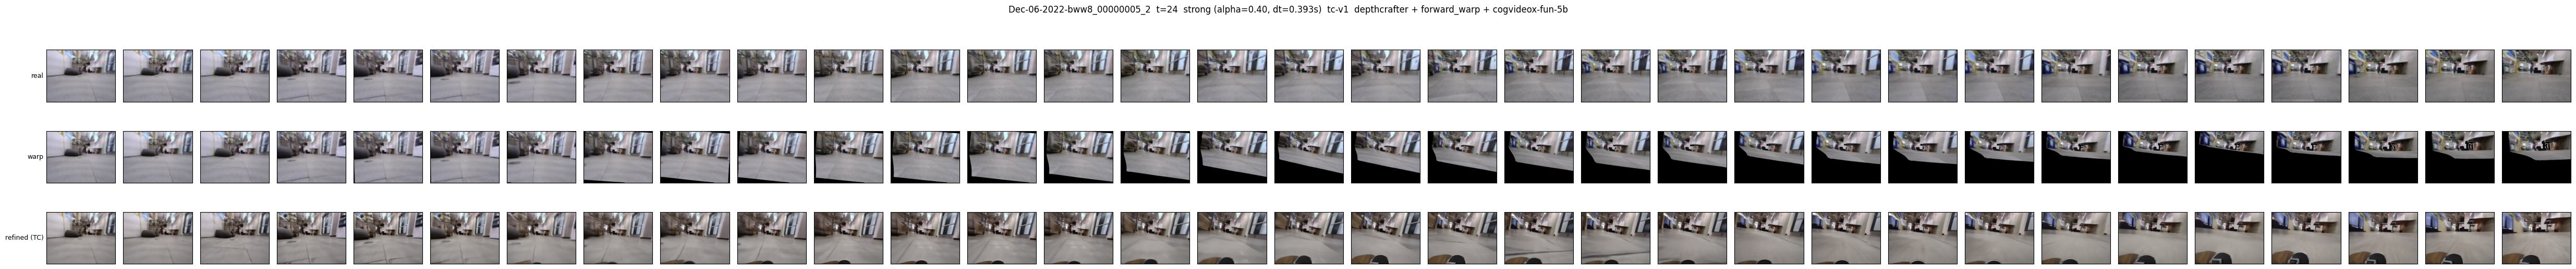

no counterfactual .npz in /content/bc_cache/train


In [35]:
from IPython.display import Video, display


def diag():
    print("TC renderer ver   :", globals().get("TC_VER", "<Section 5 not run>"))
    print("Drive mounted     :", os.path.ismount("/content/drive") or os.path.exists("/content/drive/MyDrive"))
    print("DRIVE_ROOT exists  :", os.path.isdir(DRIVE_ROOT), "->", DRIVE_ROOT)
    print("HF weight cache    :", os.path.isdir(TC_HF_CACHE), "->", TC_HF_CACHE)
    print("manifest exists    :", os.path.exists(MANIFEST_PATH))
    m = load_manifest() if os.path.exists(MANIFEST_PATH) else {}
    errs = [k for k in m if "error" in m[k]]
    print("manifest entries   : %d  (%d ok, %d errored)" % (len(m), len(m) - len(errs), len(errs)))
    if errs:
        print("  first error      :", m[errs[0]]["error"][:200])
    print("clips on Drive     :", len(glob.glob(os.path.join(CLIP_DIR, "*", "*", "t*"))))
    for s in ("train", "test"):
        print("npz cached (%s)  : %d" % (s, len(glob.glob(os.path.join(CACHE_DIR, s, "**", "*.npz"), recursive=True))))


diag()


def _clip_from(split, which):
    key = sorted(_h5[split].keys())[which]
    got = label_traj(split, key)
    if got is None:
        return None
    frames, fids, v, w, dt, poses, med_step = got
    clip_rgb = [undistort(to_rgb(frames[int(fids[i])])) for i in range(CLIP_LO, TH_HISTORY)]
    return key, clip_rgb, poses[:WINDOW_N][CLIP_LO:TH_HISTORY]


@torch.no_grad()
def tc_selftest(split="test", which=0):
    """Identity check: render with pert := real (pose_s == pose_t). The warp is a
    no-op and the refined clip should ~match the real frames -- isolates depth /
    convention / domain gap from the perturbation."""
    got = _clip_from(split, which)
    if got is None:
        print("too short"); return
    key, clip_rgb, real_win = got
    g, wp, real_used, dinfo = tc_render_refine(clip_rgb, real_win, real_win, want_warp=True)
    real_s = real_used.astype(np.float32)
    l1 = float(np.abs(g.astype(np.float32) - real_s).mean() / 255.0)
    hole = float(1.0 - (wp.astype(np.float32).sum(-1) > 4).mean())
    print("depth:", dinfo)
    ncol = min(len(g), 9)
    cols = np.linspace(0, len(g) - 1, ncol).round().astype(int)
    fig, ax = plt.subplots(3, ncol, figsize=(1.5 * ncol, 4.6))
    for c, i in enumerate(cols):
        for r, im in enumerate((real_s[i].astype(np.uint8), wp[i], g[i])):
            ax[r][c].imshow(im); ax[r][c].axis("off")
    for r, lab in enumerate(("real", "warp (identity)", "refined")):
        ax[r][0].set_ylabel(lab, rotation=0, ha="right", va="center", fontsize=9)
    fig.suptitle("%s | identity L1 = %.3f (want < ~0.12) | hole %.3f | disparity=%s scale=%.3f"
                 % (key, l1, hole, dinfo["disparity"], dinfo["scale"]))
    plt.tight_layout(); plt.show(); plt.close(fig)


@torch.no_grad()
def tc_probe(split="test", which=0, shift_m=0.20):
    """Warp-only convention check: move the camera `shift_m` to the LEFT with no
    other change and measure how the image content moves (median optical flow).
    A correct (pose convention, depth sign, FOV) setup gives dx > 0 (content
    slides RIGHT), dy ~ 0, low spatial spread, modest hole fraction. Prints all
    four (TC_POSE_W2C x depth-sign) combos so you can set them in Section 2."""
    got = _clip_from(split, which)
    if got is None:
        print("too short"); return
    key, clip_rgb, real_win = got
    Hs, Ws = TC_SAMPLE_SIZE
    i0 = len(clip_rgb) // 2
    im = cv2.resize(clip_rgb[i0], (Ws, Hs), interpolation=cv2.INTER_AREA)
    K_np = sacson_K(Hs, Ws)
    K = torch.tensor(K_np, dtype=torch.float32, device=device)[None]
    fr = torch.from_numpy(im.astype(np.float32) / 127.5 - 1.0).permute(2, 0, 1)[None].to(device)
    raw = _depthcrafter_raw((im.astype(np.float32) / 255.0)[None])
    x, y, th = real_win[i0]
    xl, yl = x - shift_m * math.sin(th), y + shift_m * math.cos(th)          # world "left" of heading
    g0 = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
    exp_px = K_np[0, 0] * shift_m / max(float(np.median(metric_depth(raw, K_np)[0])), 1e-3)
    print("%s | camera %.2f m LEFT -> content should slide RIGHT ~%.0f px, dy~0" % (key, shift_m, exp_px))
    print("  w2c    sign        dx     dy   spread  hole%")
    for w2c in (False, True):
        for sign in ("depth", "disparity"):
            dep, _di = metric_depth(raw, K_np, sign=sign)
            dt_ = torch.from_numpy(dep).to(device)[:, None]
            ps = torch.from_numpy(world_from_cam(x, y, th, w2c=w2c)).float().to(device)[None]
            pt = torch.from_numpy(world_from_cam(xl, yl, th, w2c=w2c)).float().to(device)[None]
            wf, mk, _, _ = pvd.funwarp.forward_warp(fr, None, dt_, ps, pt, K, None, True, twice=False)
            wi = (((wf[0].permute(1, 2, 0).clamp(-1, 1).cpu().numpy() + 1) * 127.5)).astype(np.uint8)
            g1 = cv2.cvtColor(wi, cv2.COLOR_RGB2GRAY)
            fl = cv2.calcOpticalFlowFarneback(g0, g1, None, 0.5, 3, 21, 3, 5, 1.2, 0)
            val = (mk[0, 0].cpu().numpy() > 0.5) & (g1 > 3)
            if val.sum() < 50:
                print("  %-5s  %-10s   (degenerate)" % (w2c, sign)); continue
            dx, dy = float(np.median(fl[..., 0][val])), float(np.median(fl[..., 1][val]))
            spread = float(np.std(fl[..., 0][val]))
            print("  %-5s  %-10s  %+6.1f %+6.1f  %6.1f  %4.0f%%"
                  % (w2c, sign, dx, dy, spread, 100 * (1 - val.mean())))


def show_undistort(split="test", which=0, n=4):
    """fisheye vs pinhole-remapped frames -- straight lines should come out straight.
    Tune SACSON_FISHEYE_FOV_DEG / SACSON_HFOV_DEG in Section 2."""
    key = sorted(_h5[split].keys())[which]
    frs = load_traj(split, key)
    idx = np.linspace(5, len(frs) - 6, n).astype(int)
    fig, ax = plt.subplots(2, n, figsize=(3 * n, 5.2))
    for c, i in enumerate(idx):
        raw = to_rgb(frs[int(i)])
        ax[0][c].imshow(raw); ax[0][c].axis("off")
        ax[1][c].imshow(undistort(raw)); ax[1][c].axis("off")
    ax[0][0].set_ylabel("fisheye", rotation=0, ha="right", va="center")
    ax[1][0].set_ylabel("pinhole", rotation=0, ha="right", va="center")
    fig.suptitle("%s | fisheye %.0f deg -> pinhole %.0f deg" % (key, SACSON_FISHEYE_FOV_DEG, SACSON_HFOV_DEG))
    plt.tight_layout(); plt.show(); plt.close(fig)


def peek_now(split="train", level="strong", which=0):
    """Reprocess ONE trajectory right now (no manifest write), wiping its old clip
    first, so you eyeball the CURRENT code's output rather than a cached jpg."""
    k = sorted(_h5[split].keys())[which]
    shutil.rmtree(os.path.join(CLIP_DIR, k), ignore_errors=True)
    print("reprocessing", split, k, "...")
    print("  ->", traj_to_bc_samples(split, k, level, save_clip=True))
    for cd in sorted(glob.glob(os.path.join(CLIP_DIR, k, "*", "t*"))):
        show_clip(only=cd)


def show_clip(n=3, save_mp4=True, fps=4, only=None):
    dirs = [only] if only else sorted(glob.glob(os.path.join(CLIP_DIR, "*", "*", "t*")))
    if not dirs or not dirs[0]:
        print("no clips under", CLIP_DIR, "-- run Section 8 with SAVE_CLIPS_FOR_FIRST_N > 0, or peek_now()")
        return
    for cd in ([only] if only else dirs[:n]):
        meta = json.load(open(os.path.join(cd, "meta.json")))
        def _load(tag):
            return [cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB) for p in sorted(glob.glob(cd + "/%s_*.jpg" % tag))]
        real, warp, gen = _load("real"), _load("warp"), _load("gen")
        H, W = gen[0].shape[:2]
        _st = max(1, len(gen) // 17)                       # thin dense (supersampled) clips for display
        rows = [("real", real[::_st]), ("warp", warp[::_st]), ("refined (TC)", gen[::_st])]
        rows = [(lab, [cv2.resize(im, (W, H)) for im in ims]) for lab, ims in rows if ims]
        cols = max(len(r[1]) for r in rows)
        fig, ax = plt.subplots(len(rows), cols, figsize=(1.5 * cols, 1.9 * len(rows)), squeeze=False)
        for r, (label, imgs) in enumerate(rows):
            for c in range(cols):
                ax[r][c].set_xticks([]); ax[r][c].set_yticks([])
                if c < len(imgs):
                    ax[r][c].imshow(imgs[c])
            ax[r][0].set_ylabel(label, rotation=0, ha="right", va="center", fontsize=9)
        fig.suptitle("%s  t=%d  %s (alpha=%.2f, dt=%.3fs)  %s"
                     % (meta["key"], meta["anchor_frame_id"], meta["level"], meta["alpha"],
                        meta.get("dt", 0), meta.get("tc_ver", "")))
        plt.tight_layout(); plt.show(); plt.close(fig)

        if save_mp4 and gen:
            mp4 = cd + "/rollout.mp4"
            vw = cv2.VideoWriter(mp4, cv2.VideoWriter_fourcc(*"mp4v"), max(fps, 4 * TC_SUPERSAMPLE), (W, H))
            for im in gen:
                vw.write(cv2.cvtColor(cv2.resize(im, (W, H)), cv2.COLOR_RGB2BGR))
            vw.release()
            display(Video(mp4, embed=True, width=W * 2))


def show_pair(idx=0, split="train"):
    cfs = sorted(glob.glob(os.path.join(CACHE_DIR, split, "*", "*_counterfactual.npz")))
    if not cfs:
        print("no counterfactual .npz in", os.path.join(CACHE_DIR, split))
        return
    cf = np.load(cfs[idx])
    nom = np.load(cfs[idx].replace("_counterfactual.npz", "_nominal.npz"))
    ncol = CONTEXT_SIZE + 2
    fig, ax = plt.subplots(3, ncol, figsize=(2 * ncol, 6),
                           gridspec_kw={"height_ratios": [1, 1, 1.3]})
    for c in range(CONTEXT_SIZE + 1):
        ax[0][c].imshow(nom["obs"][c]); ax[1][c].imshow(cf["obs"][c])
    ax[0][-1].imshow(nom["goal"]); ax[1][-1].imshow(cf["goal"])
    for r in (0, 1):
        for c in range(ncol):
            ax[r][c].set_xticks([]); ax[r][c].set_yticks([])
    ax[0][0].set_ylabel("nominal\nobs -> goal", rotation=0, ha="right", va="center", fontsize=9)
    ax[1][0].set_ylabel("counterfactual\n(TrajectoryCrafter) -> goal", rotation=0, ha="right", va="center", fontsize=9)
    for c in range(2, ncol):
        ax[2][c].axis("off")
    gs = ax[2][0].get_gridspec()
    for c in range(2):
        ax[2][c].remove()
    axw = fig.add_subplot(gs[2, :2])
    axw.plot(nom["action"][:, 0], nom["action"][:, 1], "k-o", ms=4, label="nominal label")
    axw.plot(cf["action"][:, 0], cf["action"][:, 1], "r--o", ms=4, label="recovery label")
    axw.set_aspect("equal"); axw.set_title("waypoint labels (local frame, m)"); axw.legend(fontsize=8)
    fig.suptitle("%s  t=%s" % (str(cf["key"]), str(cf["t"])))
    plt.tight_layout(); plt.show(); plt.close(fig)


show_clip()
show_pair()


## 9. Dataset + ViNT policy + training

Trains on whatever is in `CACHE_DIR`. Set `PULL_FULL_DATASET = True` to first
pull the whole accumulated dataset from the HF dataset repo.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from vint_train.models.vint.vint import ViNT

PULL_FULL_DATASET = False
if PULL_FULL_DATASET:
    from huggingface_hub import snapshot_download
    snapshot_download(DATA_REPO_ID, repo_type="dataset", local_dir=CACHE_DIR,
                      token=HF_TOKEN, allow_patterns=["*.npz"])

_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


class BCCacheDataset(Dataset):
    def __init__(self, split, train_aug):
        self.files = sorted(glob.glob(os.path.join(CACHE_DIR, split, "**", "*.npz"), recursive=True))
        self.train_aug = train_aug

    def __len__(self):
        return len(self.files)

    def _aug(self, imgs):
        s = random.uniform(0.85, 1.0)
        H, W = IMAGE_SIZE[1], IMAGE_SIZE[0]
        ch, cw = int(round(H * s)), int(round(W * s))
        top, left = random.randint(0, H - ch), random.randint(0, W - cw)
        bri, con = random.uniform(0.8, 1.2), random.uniform(0.8, 1.2)
        out = []
        for im in imgs:
            im = cv2.resize(im[top:top + ch, left:left + cw], IMAGE_SIZE, interpolation=cv2.INTER_LINEAR).astype(np.float32)
            out.append(np.clip((im - 128) * con + 128 * bri, 0, 255))
        return out

    def _norm(self, im):
        t = torch.from_numpy(np.ascontiguousarray(im)).permute(2, 0, 1).float() / 255.0
        return (t - _MEAN) / _STD

    def __getitem__(self, i):
        d = np.load(self.files[i])
        obs, goal = list(d["obs"]), d["goal"]
        if self.train_aug:
            aug = self._aug(obs + [goal])
            obs, goal = aug[:-1], aug[-1]
        obs_t = torch.cat([self._norm(o) for o in obs], dim=0)
        return obs_t, self._norm(goal), torch.from_numpy(d["action"].astype(np.float32)), torch.tensor(float(d["dist"]))


train_ds = BCCacheDataset("train", AUG)
val_ds = BCCacheDataset("test", False)
print("train %d | val %d" % (len(train_ds), len(val_ds)))
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
                      pin_memory=True, drop_last=len(train_ds) > BATCH_SIZE)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

vint = ViNT(context_size=CONTEXT_SIZE, len_traj_pred=LEN_TRAJ_PRED, learn_angle=True,
            obs_encoder="efficientnet-b0", obs_encoding_size=VINT_OBS_ENCODING_SIZE, late_fusion=False,
            mha_num_attention_heads=VINT_MHA, mha_num_attention_layers=VINT_MHA, mha_ff_dim_factor=VINT_MHA)
try:
    from efficientnet_pytorch import EfficientNet
    _m, _u = vint.obs_encoder.load_state_dict(EfficientNet.from_pretrained("efficientnet-b0").state_dict(), strict=False)
    print("obs_encoder ImageNet init (%d/%d missing/unexpected)" % (len(_m), len(_u)))
except Exception as e:
    print("ImageNet init skipped:", e)

VINT_CONFIG = dict(context_size=CONTEXT_SIZE, len_traj_pred=LEN_TRAJ_PRED, learn_angle=True,
                   obs_encoder="efficientnet-b0", obs_encoding_size=VINT_OBS_ENCODING_SIZE, late_fusion=False,
                   mha_num_attention_heads=VINT_MHA, mha_num_attention_layers=VINT_MHA, mha_ff_dim_factor=VINT_MHA,
                   image_size=list(IMAGE_SIZE), goal_horizon=GOAL_HORIZON, waypoint_scale=WAYPOINT_SCALE,
                   step_offsets=STEP_OFFSETS.tolist(), perturbation_levels=PERTURBATION_LEVELS,
                   counterfactual_source="trajectorycrafter-cogvideox-fun-5b",
                   tc_clip_len=TC_CLIP_LEN, sacson_hfov_deg=SACSON_HFOV_DEG, data_repo=DATA_REPO_ID)

if RESUME_FROM_HF:
    try:
        from huggingface_hub import hf_hub_download as _dl
        from safetensors.torch import load_file as _lsf
        _rid = "%s/%s" % (HF_USER, REPO_NAME)
        vint.load_state_dict(_lsf(_dl(_rid, "model.safetensors", token=HF_TOKEN)), strict=True)
        print("warm-started from", _rid)
    except Exception as e:
        print("no HF warm-start:", e)
vint = vint.to(device)

In [ ]:
def compute_loss(dp, ap, al, dl, alpha=ALPHA):
    dloss = F.mse_loss(dp.squeeze(-1), dl)
    aloss = F.mse_loss(ap, al)
    with torch.no_grad():
        wc = F.cosine_similarity(ap[..., :2], al[..., :2], dim=-1).mean()
    return (1 - alpha) * aloss + alpha * 1e-2 * dloss, aloss.detach(), wc


opt = torch.optim.AdamW(vint.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
spe = max(1, len(train_dl))
tot_steps, warm = EPOCHS * spe, WARMUP_EPOCHS * spe
sched = torch.optim.lr_scheduler.LambdaLR(
    opt, lambda s: s / max(1, warm) if s < warm else 0.5 * (1 + math.cos(math.pi * min(1.0, (s - warm) / max(1, tot_steps - warm)))))
scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and device.type == "cuda"))


@torch.no_grad()
def evaluate():
    vint.eval()
    tot = cos = n = 0.0
    for obs, goal, act, dist in val_dl:
        obs, goal, act, dist = obs.to(device), goal.to(device), act.to(device), dist.to(device)
        with torch.autocast(device_type=device.type, enabled=(USE_AMP and device.type == "cuda")):
            dp, ap = vint(obs, goal)
            t, _, wc = compute_loss(dp, ap, act, dist)
        b = obs.size(0); tot += t.item() * b; cos += wc.item() * b; n += b
    return (tot / n, cos / n) if n else (float("nan"), float("nan"))


@torch.no_grad()
def rollout_plot(ep):
    vint.eval()
    obs, goal, act, _ = next(iter(val_dl if len(val_ds) else train_dl))
    _, ap = vint(obs.to(device), goal.to(device))
    ap, act = ap.float().cpu().numpy(), act.numpy()
    m = min(4, obs.size(0))
    fig, ax = plt.subplots(1, m, figsize=(4 * m, 4), squeeze=False)
    for j in range(m):
        ax[0][j].plot(act[j, :, 0], act[j, :, 1], "k-o", ms=3, label="label")
        ax[0][j].plot(ap[j, :, 0], ap[j, :, 1], "r--o", ms=3, label="pred")
        ax[0][j].set_aspect("equal")
        if j == 0:
            ax[0][j].legend()
    fig.suptitle("epoch %d" % ep); plt.show(); plt.close(fig)


assert len(train_ds) > 0, "empty training cache -- run Section 8, or set PULL_FULL_DATASET"
best = float("inf"); step = 0
for ep in range(EPOCHS):
    vint.train()
    run = defaultdict(float); seen = 0
    for obs, goal, act, dist in train_dl:
        obs, goal, act, dist = obs.to(device), goal.to(device), act.to(device), dist.to(device)
        with torch.autocast(device_type=device.type, enabled=(USE_AMP and device.type == "cuda")):
            dp, ap = vint(obs, goal)
            loss, aloss, wc = compute_loss(dp, ap, act, dist)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step(); step += 1
        b = obs.size(0); seen += b
        run["t"] += loss.item() * b; run["a"] += aloss.item() * b; run["c"] += wc.item() * b
    seen = max(seen, 1)
    vt, vc = evaluate()
    crit = vt if not math.isnan(vt) else run["t"] / seen
    print("ep %3d | lr %.2e | train %.4f (act %.4f wpcos %.3f) | val %.4f (wpcos %.3f)"
          % (ep, sched.get_last_lr()[0], run["t"] / seen, run["a"] / seen, run["c"] / seen, vt, vc))
    if ep % 10 == 0 or ep == EPOCHS - 1:
        rollout_plot(ep)
    if crit < best:
        best = crit
        torch.save({"model": vint.state_dict(), "config": VINT_CONFIG, "epoch": ep,
                    "val_total": float(vt), "val_wp_cos": float(vc)}, os.path.join(CKPT_DIR, "best.pt"))
print("best:", best)

## 10. Publish the policy

In [ ]:
from huggingface_hub import upload_folder
from safetensors.torch import save_file

repo_id = "%s/%s" % (HF_USER, REPO_NAME)
create_repo(repo_id, private=True, exist_ok=True, token=HF_TOKEN, repo_type="model")
EXP = "/content/hf_export"
shutil.rmtree(EXP, ignore_errors=True); os.makedirs(EXP)

bestc = torch.load(os.path.join(CKPT_DIR, "best.pt"), map_location="cpu")
save_file(bestc["model"], os.path.join(EXP, "model.safetensors"))

manifest = load_manifest()
cfg = dict(VINT_CONFIG, trained_from_scratch=True, obs_encoder_init="imagenet",
           n_trajectories_processed=len([k for k in manifest if "error" not in manifest[k]]),
           n_train_samples=len(glob.glob(os.path.join(CACHE_DIR, "train", "**", "*.npz"), recursive=True)),
           n_val_samples=len(glob.glob(os.path.join(CACHE_DIR, "test", "**", "*.npz"), recursive=True)),
           best_val_total_loss=bestc["val_total"], best_val_wp_cos=bestc["val_wp_cos"], best_epoch=bestc["epoch"])
with open(os.path.join(EXP, "config.json"), "w") as f:
    json.dump(cfg, f, indent=2)

card = "\n".join([
    "---", "license: cc-by-nc-4.0",
    "tags: [robotics, visual-navigation, behavior-cloning, vint, sacson, world-model]", "---", "",
    "# ViNT-SACSoN corrective policy (TrajectoryCrafter counterfactuals)", "",
    "ViNT goal-conditioned navigation policy **trained from scratch** on corrective",
    "behaviour-cloning data. Drift-then-recover history frames are produced with",
    "[TrajectoryCrafter](https://github.com/TrajectoryCrafter/TrajectoryCrafter): the",
    "real [SACSoN/HuRoN](https://sites.google.com/view/sacson-review) frames are",
    "depth-warped onto a perturbed camera path and refined by CogVideoX-Fun-5B;",
    "nominal samples keep the real frames. Poses are MBRA-relabelled. Training data:",
    "`%s`." % cfg["data_repo"], "",
    "Inputs: `obs_img [B,%d,%d,%d]`, `goal_img [B,3,%d,%d]` -> `(dist, action[B,%d,4])`"
    % (3 * (CONTEXT_SIZE + 1), IMAGE_SIZE[1], IMAGE_SIZE[0], IMAGE_SIZE[1], IMAGE_SIZE[0], LEN_TRAJ_PRED),
    "(cumulative local waypoints x,y,cos,sin in metres).", "",
    "```python",
    "from vint_train.models.vint.vint import ViNT",
    "import json, safetensors.torch as st",
    "c = json.load(open('config.json'))",
    "k = ['context_size','len_traj_pred','learn_angle','obs_encoder','obs_encoding_size',",
    "     'late_fusion','mha_num_attention_heads','mha_num_attention_layers','mha_ff_dim_factor']",
    "m = ViNT(**{x: c[x] for x in k}); m.load_state_dict(st.load_file('model.safetensors')); m.eval()",
    "```", "",
    "## Limitations",
    "- Counterfactual frames are **geometry-warped + diffusion-refined**, not real",
    "  observations: disocclusions from the lateral drift are hallucinated by",
    "  CogVideoX-Fun, and 120x160 SACSoN frames are upscaled for the renderer.",
    "- Poses MBRA-estimated; `dt` calibrated from the dataset `position` attr.",
    "- SACSoN spans 3 buildings -- weak out-of-distribution transfer.",
    "- CC-BY-NC 4.0; see also the TrajectoryCrafter and CogVideoX-Fun model licenses.", "",
    "Best epoch %d: val loss %.4f, val waypoint cos-sim %.3f."
    % (bestc["epoch"], bestc["val_total"], bestc["val_wp_cos"]),
])
with open(os.path.join(EXP, "README.md"), "w") as f:
    f.write(card)

upload_folder(folder_path=EXP, repo_id=repo_id, token=HF_TOKEN, repo_type="model")
print("model  ->", "https://huggingface.co/" + repo_id)
print("data   ->", "https://huggingface.co/datasets/" + DATA_REPO_ID)
print("manifest ->", MANIFEST_PATH)

## 11. Notes

- The sample cache (`/content/bc_cache`) is **not wiped** — it mirrors the HF
  dataset repo. Re-run Section 8 in new sessions to process more trajectories
  (manifest-resumed), then Section 9–10 to retrain on the larger set
  (`PULL_FULL_DATASET = True` to pull everything first).
- Speed knobs: `TC_DIFFUSION_STEPS`, `TC_CLIP_LEN`, `TC_SAMPLE_SIZE`, `MAX_SAMPLES_PER_TRAJ`,
  `SAMPLE_STRIDE`. Generation is the bottleneck (~1-3 min/clip on an A100); the
  manifest makes it resumable across sessions.
- First-run checks: `tc_probe()` (camera-left -> content should slide right, dy~0)
  to pick `TC_POSE_W2C` / `TC_DEPTH_SIGN`; then `tc_selftest()` (identity render
  should ~match real); then eyeball a `counterfactual_clips/<key>/` rollout. If the
  warp is over/under-shot, tune `SACSON_HFOV_DEG`. `TC_SUPERSAMPLE` trades render
  time for a smoother drift.

In [ ]:
print("nothing to clean up -- data kept in", CACHE_DIR, "and", DATA_REPO_ID)